# Рекомендации банковских продуктов

**Бизнес задача**: Имеются данные о поведении клиентов банка за 1 год и 5 месяцев — на их основе необходимо предсказать, какие новые продукты купят клиенты. Данные начинаются с 28 января 2015 года и содержат ежемесячные записи о продуктах, которыми воспользовался клиент, например, «кредитная карта», «сберегательный счет» и т. д. Необходимо предсказать, какие дополнительные продукты клиент получит в новом месяце. 

**Цель**: Подготовить модель машинного обучения, которая на имеющихся данных предскажет какими новыми банковскими продуктами воспользуется клиент в будущем месяце.

**Дополнительно**: 
1. В качестве новых банковских продуктов выбраны продукты, которые не использовались в текущем месяце.
2. В качестве тестовой выборки решено оставить последний месяц 2016 года. При этом: 
    - для модели с двухстадийным подходом использовать 2015 год для обучения модели ALS, а для ранжирующей модели первый квартал 2016 года;
    - для модели multi-label классификации использовать весь датасет кроме тестового, а первый квартал 2016 года может использоваться для валидации.

**Метрики**
- Основная метрика: **MAP@3**
- Дополнительные метрики: Precision@3, Recall@3

## Инициализация

In [1]:
# Импорт стандартных библиотек
import sys
import os
import gc
import warnings
# Подавляем warnings от библиотек
# pydantic об изменении схемы и 
# tqdm об отсуствии IProgress
warnings.filterwarnings("ignore")

# Импорт библиотек
import pandas as pd
import numpy as np
import joblib
import mlflow
import json
from tqdm import tqdm
from dotenv import load_dotenv
from mlflow.pyfunc import PythonModel
from mlflow.models.signature import infer_signature
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix
from threadpoolctl import threadpool_limits
from implicit.als import AlternatingLeastSquares
from sklearn.neighbors import NearestNeighbors
from catboost import CatBoostClassifier

In [2]:
# Объявление констант
load_dotenv()

RANDOM_STATE = 42
PERCENTILES = [.01, .05, .25, .5, .75, .95, .99]

# Данные для подключения к MLflow
MLFLOW_HOST = os.getenv("MLFLOW_HOST") 
MLFLOW_PORT = os.getenv("MLFLOW_PORT")
MLFLOW_URI = f"http://{MLFLOW_HOST}:{MLFLOW_PORT}"

EXPERIMENT_NAME = "bank_products_3PX"
REGISTRY_MODEL_NAME = "bank_products_3PX"

MLFLOW = True

# Данные для сохранения тестовой выборки в S3 
# для использования в сервисе предсказаний
STORAGE_OPTIONS = {
    "endpoint_url": os.getenv("MLFLOW_S3_ENDPOINT_URL"), 
    "key": os.getenv("AWS_ACCESS_KEY_ID"), 
    "secret": os.getenv("AWS_SECRET_ACCESS_KEY"),
    "client_kwargs":{
        "region_name": os.getenv("AWS_REGION")},
    "config_kwargs": {
        "signature_version": os.getenv("AWS_SIGV")}}
TEST_DUMP = (f"s3://{os.getenv('S3_BUCKET')}/"
             f"{os.getenv('BP_DATA_FILE')}")

# Настройки вывода pandas
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('plotting.backend', 'plotly')

# Увеличиваем частоту очистки памяти
gc.set_threshold(10, 3, 2)

Подготовим функцию для получения метрик.

In [3]:
def get_metrics(y_true, y_pred, 
                k: int = 3, 
                suffix: str = ""):
    """
    Вычисляет MAP@k, Precision@k, Recall@k для multi-label задачи.

    Parameters
    ----------
    y_true : список списков 0/1 (разметка, что выбрал пользователь)
    y_pred : список списков вероятностей по тем же продуктам
    k      : число top-k предсказаний
    suffix : суффикс к названию метрик

    Returns
    -------
    dict с метриками
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    assert y_true.shape == y_pred.shape, "y_true и y_pred должны иметь одинаковый размер"
    assert y_pred.ndim == 2, "Ожидается двумерный массив (n_samples, n_items)"
    n_samples, n_items = y_pred.shape
    k = min(k, n_items)

    # MAP@k
    avg_precisions = []
    for true_row, pred_row in zip(y_true, y_pred):
        top_k = np.argsort(-pred_row)[:k]
        rel = true_row[top_k]
        precisions = np.cumsum(rel) / (np.arange(k) + 1)
        if np.sum(rel) > 0:
            ap = np.sum(precisions * rel) / np.sum(rel)
        else:
            ap = 0.0
        avg_precisions.append(ap)
    map_k = np.mean(avg_precisions)

    # Precision@k
    top_k = np.argsort(-y_pred, axis=1)[:, :k]
    rel = np.take_along_axis(y_true, top_k, axis=1)
    precision = np.mean(np.sum(rel, axis=1) / k)

    # Recall@k
    recalls = []
    for true_row, rel_row in zip(y_true, rel):
        n_relevant = np.sum(true_row)
        if n_relevant == 0:
            continue
        recalls.append(np.sum(rel_row) / n_relevant)
    recall = np.mean(recalls) if recalls else 0.0

    return {
        f"MAP-{k}{suffix}": map_k,
        f"Precision-{k}{suffix}": precision,
        f"Recall-{k}{suffix}": recall
    }

Так как модели достаточно долго обучаются будем сохранять модели и логи их обучения в файлы для повторного использования. Для сохранения логов подготовим класс для разеделния вывода, а также функцию для загрузки либо обучения модели.

In [4]:
class OutTee:
    def __init__(self, *streams):
        self.streams = streams

    def write(self, data):
        for s in self.streams:
            s.write(data)
            s.flush()

    def flush(self):
        for s in self.streams:
            s.flush()

def cb_load_or_fit(model, model_file, log_file, 
                   X, y, eval_set=None,
                   early_stopping_rounds=None,
                   use_best_model=None):
    if os.path.exists(model_file):
        model.load_model(model_file)
        if os.path.exists(log_file):
            with open(log_file, "r") as fd:
                print(fd.read())
    else:
        fd = open(log_file, "w")
        original_stdout = sys.stdout
        sys.stdout = OutTee(sys.stdout, fd)
        model.fit(
            X, y, eval_set=eval_set, 
            early_stopping_rounds=early_stopping_rounds,
            use_best_model=use_best_model)
        model.save_model(model_file)
        sys.stdout = original_stdout
        fd.close()
    return model

Настроим подключение к серверу MLflow и получим ID эксперимента.

> ⚠️ **ВАЖНО!!!** 
> Для выполенния последующего кода необходимо запустить MLflow. Для этого подготовлен скрипт в корневой директории проекта [run-mlflow.sh](run-mlflow.sh)

In [5]:
# Подключение к локальному серверу MLflow
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_registry_uri(MLFLOW_URI)
client = mlflow.MlflowClient()

# получение ID эксперимента
if MLFLOW:
    if mlflow.get_experiment_by_name(EXPERIMENT_NAME):
        experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
    else:
        experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)

## Логирование результатов EDA в MLflow

В Jupyter блокноте [EDA.ipynb](EDA/EDA.ipynb) проведен глубокий исследовательский анализ данных:
- удалены все записи с пропусками по большинству полей, остальные пропуски заполнены на основании последующих значений у клиента, либо заглушками типа `unknown`;
- в датасете было выявлено большое количество аномалий, которые были исправлены;
- пропуски по доходу были заполнены нулями, так как нет понимания насколько актуальны эти сведения для старых клиентов, в датасете имеются несовершеннолетние и могут быть безработные, иждивенцы, либо находящиеся на социальном обеспечении клиенты. Также возможно не для всех продуктов запрашивались сведения по доходам и точно не запрашивались для резидентов других стран;
- выбросы были исправлены только по возрасту клиентов, так как при анализе признака, в том числе по банковским продуктам, имелись подозрения на наличие выбросов. Для этого была подготовлена регрессионная модель Random Forest и значения с самыми большими остатками были исправлены на предсказания модели;
- подготовлен трансформер для всех преобразований датасета.

Интерактивные графики Plotly, полученные при проведении EDA, а также трансформер для преобразования датасета сохранены в директории [ASSETS](EDA/ASSETS/). Логируем результаты EDA в MLflow, сохраним трансформер как артефакттакт, так как он используется только для препроцессинга до тренировки моделей. Тем более при попытке сохранить его как модель с добавлением сигнатуры и примера входящих данных, метаданные модели превышают установленный лимит в 5000 символов и не сохраняются в tracking-сервере.

In [6]:
if MLFLOW:
    with mlflow.start_run(run_name="EDA", experiment_id=experiment_id) as run:
        # Логирование ноутбука и дополнительных файлов
        for file in os.listdir("EDA"):
            if os.path.isfile(file):
                mlflow.log_artifact(os.path.join("EDA", file))
        # Логирование содержимого папки ASSETS
        eda_assets = os.path.join("EDA", "ASSETS")
        for asset in os.listdir(eda_assets):
            file = os.path.join(eda_assets, asset)
            if os.path.isfile(file):
                # Логирование трансформера и сопутствующих файлов
                mlflow.log_artifact(file, "transformer")
            elif asset in ["plots"]:
                # Логирование прочих артефактов из папок
                mlflow.log_artifacts(asset, asset)
    print("Run ID:", run.info.run_id)

Run ID: 9d714234b6614f3ab3456e6b4252d8a6


Результаты EDA логированы.

## Подготовка и разделение датасета

Загрузим очищенный датасет.

In [7]:
df = pd.read_parquet(os.path.join("data", "clean_data.parquet"))
print("Размер датасета:", df.shape)

Размер датасета: (13610316, 42)


Получим список признаков по типам.

In [8]:
target_cols = df.columns[-24:].tolist()
num_cols = ["age", "antiguedad", "renta", "fecha_dato"]
cat_cols = [col for col in df.columns[2:-24]
            if col not in num_cols]

Получим датасет с целевыми признаками путем сдвига на один месяц назад и получения тех продуктов, которых не было в предыдущем месяце. Так как в датасете имеются пропуски в записях (были удалены записи с пропусками в начале 2015 года и могут быть пропуски по месяцам) - подготовим маску для отбора записей, в которых будут только те значения, у которых разница с последующими не больше месяца.

Однако в датасете имеются записи с неактивными клиентами, которые прекратили отношения. Эти записи последние у клиента, но лучше обучить модель, что у таких пользователей в следующем месяце нет новых продуктов.

In [9]:
# Получение маски для удаления записей путем сравнения 
# разницы в днях c последующим месяцем, последний месяц 
# у клиентов - False как результат сравнения с NaN
mask = df.groupby("ncodpers")["fecha_dato"].diff(-1) \
    .abs().dt.days < 32

# Добавление записей по ушедшим клиентамм
# и исключение последнего месяца для них, 
# так как есть ушедшие в 5 месяце клиенты
last_month = df["fecha_dato"].max()
mask = (df["fecha_dato"] != last_month) & \
    (~df["indrel"]) | mask

# Получение целевых значений посредством логического И 
# между продуктами следующего месяца и инвертированными 
# значениями индикации продуктов текущего месяца
target = df.groupby("ncodpers")[target_cols] \
    .shift(-1) & (~df[target_cols])

# Исключение лишних записей (последних и перед разрывом)
target = target[mask].copy()
print(f"Исключены {(1 - mask.mean()):.2%} записей.")

Исключены 6.87% записей.


Также исключим неактуальные записи из основного датасета.

In [10]:
df = df[mask].copy()
print("Размер датасета:", df.shape)

Размер датасета: (12675669, 42)


Получим маски для разделения датасета на тестовую, тренировочную и валидационную выборки.

In [11]:
train_mask = df["fecha_dato"] < pd.to_datetime("2016-01-01")
test_mask = df["fecha_dato"] > pd.to_datetime("2016-04-01")
valid_mask = (~train_mask) & (~test_mask)
print("Записей в тренировочной выборке:", train_mask.sum())
print("Записей в валидационной выборке:", valid_mask.sum())
print("Записей в тестовой выборке:", test_mask.sum())

Записей в тренировочной выборке: 8987155
Записей в валидационной выборке: 2760691
Записей в тестовой выборке: 927823


Подготовим трансформер, который возвращает датасет и целевые признаки, очищенные от записей, по которым нет целевых значений.

In [12]:
# Параметры для трансформера
params = {
    "user_col": "ncodpers",
    "date_col": "fecha_dato",
    "rel_col": "indrel",
    "target_cols": df.columns[-24:].tolist()}

with open(os.path.join("models", "extractor_params.json"), 
          "w") as fd:
    json.dump(params, fd)

# Трансформер в виде модели pyfunc
class BankProductTargetExtractor(PythonModel):    
    def load_context(self, context):
        import json
        with open(context.artifacts["params"], "r") as fd:
            params = json.load(fd)
        self.user_col = params["user_col"]
        self.date_col = params["date_col"]
        self.rel_col = params["rel_col"]
        self.target_cols = params["target_cols"]

    def transform(self, X):
        mask = X.groupby(self.user_col)[self.date_col] \
            .diff(-1).abs().fillna(pd.Timedelta(days=32)) \
            .dt.days < 32
        last_month = X[self.date_col].max()
        mask = (X[self.date_col] != last_month) & \
            (~X[self.rel_col]) | mask
        y = X.groupby(self.user_col)[self.target_cols] \
            .shift(-1) & (~X[self.target_cols])
        return X[mask].copy(), y[mask]

    def predict(self, context, model_input):
        return self.transform(model_input)

Логируем этот трансформер в MLflow.

In [13]:
if MLFLOW:
    with mlflow.start_run(run_name="Target extractor", 
                        experiment_id=experiment_id) as run:
        mlflow.pyfunc.log_model(
            python_model=BankProductTargetExtractor(),
            artifact_path="target_extractor",
            artifacts={"params": "models/extractor_params.json"}
        )
    print("Run ID:", run.info.run_id)

Run ID: 62566da829754d1b87b36215c7a5a104


## Базовая модель с двухстадийным подходом

Подготовим двухстадийную модель рекомендаций, на первой стадии будут подготовлены рекомендации для клиентов на базе модели ALS, на второй стадии будет обучена модель классификации для ранжирования продуктов.

### Персональные рекомендации

Для обучения модели ALS подготовим матрицу взаимодействий клиента с продуктами, в качестве веса продукта будем использовать интенсивность взаимодействия в виде среднего значения по продукту у клиента.

In [14]:
als_data = df[train_mask] \
    .groupby("ncodpers")[target_cols].mean()

Закодируем клиентов и продукты для использования в модели ALS.

In [15]:
# Кодирование идентификаторов для ALS
user_enc = LabelEncoder()
item_enc = LabelEncoder()
als_data.index = user_enc.fit_transform(als_data.index)
als_data.columns = item_enc.fit_transform(als_data.columns)
# Сортировка новых идентификаторов
als_data = als_data.sort_index(axis=0).sort_index(axis=1)
als_data

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.42,1.00,0.00
1,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,...,0.00,1.00,1.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00
2,0.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,0.00,0.00,0.58,0.00,0.42,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,0.00
4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917670,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
917671,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
917672,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
917673,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Преобразуем датасет в разреженную матрицу и обучим модель implicit ALS на подготовленном датасете.

In [16]:
sparse_data = csr_matrix(als_data)

with threadpool_limits(1, "blas"):
    als_model = AlternatingLeastSquares()
    als_model.fit(sparse_data)

100%|██████████| 15/15 [00:34<00:00,  2.30s/it]


Получим рекомендации для клиентов по всем продуктам.

In [17]:
# Получение рекомендаций путем умножения факторов
client_recs = pd.DataFrame(np.dot(
    als_model.user_factors,
    als_model.item_factors.T))
# Возвращение идентификаторов
client_recs.index = user_enc.inverse_transform(
    client_recs.index)
client_recs.columns = item_enc.inverse_transform(
    client_recs.columns)
client_recs = client_recs[target_cols].sort_index()
client_recs

,ind_ahor_fin_ult1,ind_aval_fin_ult1,ind_cco_fin_ult1,ind_cder_fin_ult1,ind_cno_fin_ult1,ind_ctju_fin_ult1,ind_ctma_fin_ult1,ind_ctop_fin_ult1,ind_ctpp_fin_ult1,ind_deco_fin_ult1,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
15889,-0.00,0.00,1.00,0.00,-0.00,0.00,-0.00,0.00,1.00,-0.00,...,0.00,0.00,-0.00,0.00,0.98,1.00,-0.00,-0.00,-0.00,-0.00
15890,-0.00,-0.00,-0.04,-0.00,1.00,-0.00,0.00,0.00,1.00,-0.00,...,0.00,1.00,-0.00,-0.00,1.01,0.00,-0.00,1.01,1.01,1.00
15891,-0.00,-0.00,0.98,-0.00,0.00,-0.00,-0.00,0.01,0.00,-0.00,...,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00
15892,0.00,-0.00,0.98,-0.00,0.95,0.00,0.00,0.00,0.00,-0.00,...,0.00,0.00,0.00,1.00,1.01,1.00,0.00,-0.00,0.01,1.01
15893,-0.00,0.00,0.02,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,...,-0.00,0.00,0.00,0.00,0.00,1.00,-0.00,-0.00,-0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1520371,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1520372,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1520373,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1520375,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Датасет для обучения ранжирующей модели содержит новых клиентов, которых не было в тренировочном датасете для модели ALS. Для получения рекомендаций для таких клиентов найдем ближайших к ним клиентов с помощью косинусной близости по интенсивности использования продуктов. 

Конечно лучше обучить несколько моделей ALS скользящим окном за предыдущие 12 месяцев для получения данных на каждый месяц первого квартала 2016 года. Но для оценки базовой модели считаю достаточным получить информацию по данным за 2015 год, а по новым пользователям использовать веса за весь первый квартал 2016 года.

Также добавим клиентов из тестового выборки, которые понадобятся для подготовки датасета для тестирования модели.

In [18]:
# Получение списка новых клиентов
new_users = list(
    set(df.loc[~train_mask, "ncodpers"].unique()) - 
    set(df.loc[train_mask, "ncodpers"].unique()))
print("Количество новых пользователей:", 
      len(new_users))

Количество новых пользователей: 22694


В 2016 году появилось почти 22.7 тысяч новых клиентов, которых не было в записях 2015 года. Так как вычисление косинусного расстояния на таких больших датасетах потребует очень больших ресурсов памяти, воспользуемся моделью Nearest Neghbors для поиска ближайших клиентов.

In [19]:
# Получение использованных продуктов
als_data_new = df[~train_mask] \
    .loc[lambda x: x["ncodpers"].isin(new_users)] \
    .groupby("ncodpers")[target_cols].mean() \
    .astype("int32")
# Преобразование столбцов для соответствия
als_data_new.columns = item_enc.transform(
    als_data_new.columns)
als_data_new = als_data_new.sort_index(axis=1)
# Обучение модели NN
nn_model = NearestNeighbors(
    n_neighbors=1, 
    metric="cosine",
    n_jobs=-1)
nn_model.fit(als_data)

NearestNeighbors(metric='cosine', n_jobs=-1, n_neighbors=1)

Получим рекомендации для клиентов наиболее близких к новым и объединим датасет.

In [20]:
pers_file = os.path.join("data", "personal_als.parquet")
if not os.path.exists(pers_file):
    # Получение рекомендаций для ближайших соседей
    _, ids = nn_model.kneighbors(als_data_new)
    near_recs = pd.DataFrame(np.dot(
        als_model.user_factors[np.unique(ids)],
        als_model.item_factors.T), index=np.unique(ids))
    # Получение датасета с рекомендациями
    near_recs = pd.Series(ids.flatten(), index=als_data_new.index) \
        .map(near_recs.to_dict(orient="index")).apply(pd.Series)
    # Восстановление наименований продуктов
    near_recs.columns = item_enc.inverse_transform(
        near_recs.columns)
    near_recs = near_recs.rename_axis("")[target_cols]
    # Объединение датасетов
    client_recs = pd.concat([client_recs, near_recs])
    del _, ids, near_recs
else:
    client_recs = pd.read_parquet(pers_file)
    client_recs = client_recs.pivot(
        index="ncodpers", 
        columns="product", 
        values="als_score")[target_cols] \
            .rename_axis(None, axis=0) \
            .rename_axis(None, axis=1)
client_recs

,ind_ahor_fin_ult1,ind_aval_fin_ult1,ind_cco_fin_ult1,ind_cder_fin_ult1,ind_cno_fin_ult1,ind_ctju_fin_ult1,ind_ctma_fin_ult1,ind_ctop_fin_ult1,ind_ctpp_fin_ult1,ind_deco_fin_ult1,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
15889,-0.00,0.00,1.02,-0.00,-0.00,0.00,-0.00,0.00,1.00,-0.00,...,0.00,0.00,0.00,0.00,0.97,1.00,0.00,-0.00,-0.00,-0.00
15890,-0.00,-0.00,-0.04,-0.00,1.00,0.00,-0.00,-0.00,1.00,-0.00,...,0.00,0.99,0.00,-0.00,1.01,0.00,0.00,1.01,1.01,1.00
15891,-0.00,-0.00,0.99,0.00,0.01,0.00,-0.00,0.01,0.00,-0.00,...,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.01,0.01,0.00
15892,-0.00,0.00,1.01,-0.00,0.95,0.00,-0.00,-0.00,0.00,-0.00,...,0.00,0.00,-0.00,1.00,1.01,1.00,0.00,0.00,0.01,1.00
15893,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,...,-0.00,0.00,-0.00,0.00,0.00,1.00,-0.00,-0.00,0.00,-0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1548202,-0.00,0.00,1.02,-0.00,-0.00,0.00,-0.00,0.00,1.00,-0.00,...,0.00,0.00,0.00,0.00,0.97,1.00,0.00,-0.00,-0.00,-0.00
1548203,-0.00,0.00,1.02,-0.00,-0.00,0.00,-0.00,0.00,1.00,-0.00,...,0.00,0.00,0.00,0.00,0.97,1.00,0.00,-0.00,-0.00,-0.00
1548204,-0.00,0.00,1.02,-0.00,-0.00,0.00,-0.00,0.00,1.00,-0.00,...,0.00,0.00,0.00,0.00,0.97,1.00,0.00,-0.00,-0.00,-0.00
1548206,-0.00,0.00,1.02,-0.00,-0.00,0.00,-0.00,0.00,1.00,-0.00,...,0.00,0.00,0.00,0.00,0.97,1.00,0.00,-0.00,-0.00,-0.00


Можно отметить, что много новых клиентов получили одинаковые рекомендации, вероятно это клиенты с однотипными взаимодействиями, аналогичными клиенту с id 15889. Преобразуем рекомендации к удобному виду для добавления в признаки перед обучением модели.

In [21]:
client_recs = client_recs.reset_index(names="ncodpers") \
    .melt(
        id_vars="ncodpers", 
        var_name="product",
        value_name="als_score"
    ).sort_values(by=["ncodpers", "product"])
client_recs

,ncodpers,product,als_score
0,15889,ind_ahor_fin_ult1,-0.00
940369,15889,ind_aval_fin_ult1,0.00
1880738,15889,ind_cco_fin_ult1,1.02
2821107,15889,ind_cder_fin_ult1,-0.00
3761476,15889,ind_cno_fin_ult1,-0.00
...,...,...,...
16926641,1548207,ind_reca_fin_ult1,0.00
22568855,1548207,ind_recibo_ult1,-0.00
17867010,1548207,ind_tjcr_fin_ult1,0.97
18807379,1548207,ind_valo_fin_ult1,1.00


In [22]:
# Сохраним датасет, чтобы можно было его 
# использовать без поиска ближайших соседей
client_recs.to_parquet(pers_file, index=False)

del als_data, als_data_new, sparse_data, pers_file

### Обучение модели ранжирования

Отберем записи по целевым признакам из валидационной выборки, которые будут использоваться для обучения модели классификации.

In [23]:
train = pd.melt(
    target[valid_mask].assign(
        ncodpers=df.loc[valid_mask, "ncodpers"],
        fecha_dato=df.loc[valid_mask, "fecha_dato"]),
    id_vars=["ncodpers", "fecha_dato"],
    var_name="product", value_name="target")
print("Использованных в следующем месяце продуктов:",
      train["target"].sum())
train

Использованных в следующем месяце продуктов: 117219


,ncodpers,fecha_dato,product,target
0,15889,2016-01-28,ind_ahor_fin_ult1,False
1,15889,2016-02-28,ind_ahor_fin_ult1,False
2,15889,2016-03-28,ind_ahor_fin_ult1,False
3,15890,2016-01-28,ind_ahor_fin_ult1,False
4,15890,2016-02-28,ind_ahor_fin_ult1,False
...,...,...,...,...
66256579,1542658,2016-03-28,ind_recibo_ult1,False
66256580,1542659,2016-03-28,ind_recibo_ult1,False
66256581,1542660,2016-03-28,ind_recibo_ult1,False
66256582,1542661,2016-03-28,ind_recibo_ult1,False


Имеем очень сильный дисбаланс классов - использованных клиентами продуктов в следующем месяце порядка 117 тысяч, против 66.2 миллионов возможных вариантов использования клиентами продуктов. Чтобы модель получила больше вариантов, добавим к положительным значениям случайные отрицательные варианты в соотношении 4:1 чтобы не допускать сильного дисбаланса классов.

In [24]:
train = pd.concat([
    train[train["target"] == True],
    train[train["target"] == False].sample(
        n=train["target"].sum() * 4,
        random_state=RANDOM_STATE)
]).sort_values(by=["ncodpers", "fecha_dato"])
print("Уникальных клиентов:",
      train["ncodpers"].nunique())
train

Уникальных клиентов: 417414


,ncodpers,fecha_dato,product,target
49692439,15889,2016-02-28,ind_tjcr_fin_ult1,True
2760692,15889,2016-02-28,ind_aval_fin_ult1,False
63495896,15890,2016-01-28,ind_recibo_ult1,False
60735208,15892,2016-01-28,ind_nom_pens_ult1,False
33128301,15893,2016-01-28,ind_ecue_fin_ult1,False
...,...,...,...,...
55213813,1542654,2016-03-28,ind_valo_fin_ult1,False
8282069,1542659,2016-03-28,ind_cco_fin_ult1,True
44171052,1542659,2016-03-28,ind_plan_fin_ult1,False
8282070,1542660,2016-03-28,ind_cco_fin_ult1,True


Получено порядка 586 тысяч записей для 417 тысяч клиентов. Добавим оценки ALS и признаки клиента к тренировочной выборке.

In [25]:
# Добавление оценок ALS
train = train.merge(
    client_recs, how="left",
    on=["ncodpers", "product"])
# Добавление признаков клиента
train = train.merge(
    df[valid_mask & df["ncodpers"].isin(
        train["ncodpers"].unique())], 
    how="left", on=["ncodpers", "fecha_dato"])
# Замена даты на месяц
train["fecha_dato"] = train["fecha_dato"].dt.month
train

,ncodpers,fecha_dato,product,target,als_score,ind_empleado,sexo,age,ind_nuevo,antiguedad,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,15889,2,ind_tjcr_fin_ult1,True,0.97,F,V,56.00,False,253,...,False,False,False,False,False,True,False,False,False,False
1,15889,2,ind_aval_fin_ult1,False,0.00,F,V,56.00,False,253,...,False,False,False,False,False,True,False,False,False,False
2,15890,1,ind_recibo_ult1,False,1.00,A,V,63.00,False,252,...,False,True,False,False,True,False,False,True,True,True
3,15892,1,ind_nom_pens_ult1,False,0.01,F,H,61.00,False,252,...,False,False,False,True,True,True,False,False,False,True
4,15893,1,ind_ecue_fin_ult1,False,0.00,N,V,62.00,False,219,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586090,1542654,3,ind_valo_fin_ult1,False,1.00,N,H,38.00,True,0,...,False,False,False,False,False,False,False,False,False,False
586091,1542659,3,ind_cco_fin_ult1,True,1.02,N,V,33.00,True,0,...,False,False,False,False,False,False,False,False,False,False
586092,1542659,3,ind_plan_fin_ult1,False,0.00,N,V,33.00,True,0,...,False,False,False,False,False,False,False,False,False,False
586093,1542660,3,ind_cco_fin_ult1,True,1.02,N,H,35.00,True,0,...,False,False,False,False,False,False,False,False,False,False


Обучим модель ранжирования.

In [26]:
# Разделение датасета на фичи и таргет
cb2s_feats = ["als_score"] + num_cols + cat_cols + target_cols
X_train = train[cb2s_feats]
y_train = train["target"]

cb2s_params = dict(
    iterations=5000,
    cat_features=cat_cols + target_cols,
    verbose=500, thread_count=-1,
    random_seed=RANDOM_STATE)

# Обучение модели или загрузка если имеется
model_file = os.path.join(
    "models", "cb2s_base_model.cb")
train_log = os.path.join(
    "models", "cb2s_base_model.log")
cb2s_model = CatBoostClassifier(**cb2s_params)
cb2s_model = cb_load_or_fit(
    cb2s_model, model_file, train_log,
    X_train, y_train, 
    early_stopping_rounds=100,
    use_best_model=True)

Learning rate set to 0.035801
0:	learn: 0.6490117	total: 366ms	remaining: 30m 31s
500:	learn: 0.2051840	total: 1m 22s	remaining: 12m 23s
1000:	learn: 0.1955141	total: 2m 47s	remaining: 11m 11s
1500:	learn: 0.1906073	total: 4m 19s	remaining: 10m 4s
2000:	learn: 0.1873980	total: 5m 54s	remaining: 8m 51s
2500:	learn: 0.1849169	total: 7m 34s	remaining: 7m 34s
3000:	learn: 0.1829904	total: 9m 18s	remaining: 6m 12s
3500:	learn: 0.1812549	total: 11m 3s	remaining: 4m 44s
4000:	learn: 0.1798366	total: 12m 50s	remaining: 3m 12s
4500:	learn: 0.1784550	total: 14m 39s	remaining: 1m 37s
4999:	learn: 0.1771637	total: 16m 29s	remaining: 0us



Модель обучена, сохраним обучающую выборку и очистим переменные.

In [27]:
train.to_parquet(
    os.path.join("data", "two-stage_train.parquet"),
    index=False)
del train, X_train, y_train

### Тестирование модели

Для тестирования модели оставим все продукты по клиентам.

In [28]:
test = pd.melt(
    target[test_mask].assign(
        ncodpers=df.loc[test_mask, "ncodpers"],
        fecha_dato=df.loc[test_mask, "fecha_dato"]),
    id_vars=["ncodpers", "fecha_dato"],
    var_name="product", value_name="target")
print("Использованных в следующем месяце продуктов:",
      test["target"].sum())
test

Использованных в следующем месяце продуктов: 35843


,ncodpers,fecha_dato,product,target
0,15889,2016-04-28,ind_ahor_fin_ult1,False
1,15890,2016-04-28,ind_ahor_fin_ult1,False
2,15892,2016-04-28,ind_ahor_fin_ult1,False
3,15893,2016-04-28,ind_ahor_fin_ult1,False
4,15894,2016-04-28,ind_ahor_fin_ult1,False
...,...,...,...,...
22267747,1548202,2016-04-28,ind_recibo_ult1,False
22267748,1548203,2016-04-28,ind_recibo_ult1,False
22267749,1548204,2016-04-28,ind_recibo_ult1,False
22267750,1548206,2016-04-28,ind_recibo_ult1,False


Добавим признаки для получения предсказаний.

In [29]:
# Добавление оценок ALS
test = test.merge(
    client_recs, how="left",
    on=["ncodpers", "product"])
# Добавление признаков клиента
test = test.merge(
    df[test_mask & df["ncodpers"].isin(
        test["ncodpers"].unique())], 
    how="left", on=["ncodpers", "fecha_dato"])
# Замена даты на месяц
test["fecha_dato"] = test["fecha_dato"].dt.month
test

,ncodpers,fecha_dato,product,target,als_score,ind_empleado,sexo,age,ind_nuevo,antiguedad,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,15889,4,ind_ahor_fin_ult1,False,-0.00,F,V,56.00,False,255,...,False,False,False,False,False,True,False,False,False,False
1,15890,4,ind_ahor_fin_ult1,False,-0.00,A,V,63.00,False,255,...,False,True,False,False,True,False,False,True,True,True
2,15892,4,ind_ahor_fin_ult1,False,-0.00,F,H,62.00,False,255,...,False,False,False,True,True,True,False,False,False,True
3,15893,4,ind_ahor_fin_ult1,False,-0.00,N,V,63.00,False,222,...,False,False,False,False,False,True,False,False,False,False
4,15894,4,ind_ahor_fin_ult1,False,-0.00,A,V,60.00,False,255,...,False,False,False,True,True,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22267747,1548202,4,ind_recibo_ult1,False,-0.00,N,V,22.00,True,0,...,False,False,False,False,False,False,False,False,False,False
22267748,1548203,4,ind_recibo_ult1,False,-0.00,N,V,51.00,True,0,...,False,False,False,False,False,False,False,False,False,False
22267749,1548204,4,ind_recibo_ult1,False,-0.00,N,V,54.00,True,0,...,False,False,False,False,False,False,False,False,False,False
22267750,1548206,4,ind_recibo_ult1,False,-0.00,N,H,40.00,True,0,...,False,False,False,False,False,False,False,False,False,False


Получим рекомендации для тестовой выборки.

In [30]:
X_test = test[cb2s_feats]

probas_file = os.path.join("models", "cb2s_probas.pkl")
if os.path.exists(probas_file):
    with open(probas_file, "rb") as fd:
        probas = joblib.load(fd)
else:
    batch_size = int(np.ceil(len(X_test) / 100))
    probas = []

    for i in tqdm(range(0, len(X_test), batch_size)):
        batch = X_test.iloc[i:i + batch_size]
        b_prs = cb2s_model.predict(
            batch, thread_count=-1,
            prediction_type="Probability")
        probas.append(b_prs)

    probas = np.vstack(probas)

    with open(probas_file, "wb") as fd:
        joblib.dump(probas, fd)

Получим метрики для базовой модели рекомендаций с двухстадийным подходом. Так как датасет содержит большое количество клиентов, которые не пользовались новыми продуктами, дополнительно посчитаем метрики активных клиентов, у которых было хотя бы одно предсказание.

In [31]:
y_test = test[["ncodpers", "product", "target"]].copy()
y_test["pred"] = probas[:, 1]
y_test = y_test.pivot(index=["ncodpers"], columns="product")
metrics = get_metrics(
    y_test["target"].astype(int), 
    y_test["pred"],
    suffix="_all")
metrics.pop("Recall-3_all")
# Получим метрики для активных клиентов
mask = y_test["target"].any(axis=1)
metrics.update(get_metrics(
    y_test.loc[mask, "target"].astype(int),
    y_test.loc[mask, "pred"]))
metrics

{'MAP-3_all': 0.018247284234169672,
 'Precision-3_all': 0.008821007167674585,
 'MAP-3': 0.6073632286995516,
 'Precision-3': 0.2936083707025411,
 'Recall-3': 0.7232071748878923}

Метрики довольно низкие для всех клиентов, что не удивительно, так как большинство из них не пользуются новыми продуктами. Для активных клиентов существенно вырастают метрики MAP@3 и Precision@3, по последней можно говорить о том, что почти по одному продукту на клиента модель предсказывает среди ТОП-3. Метрика Recall@3 расчитывает только для тех клиентов, у кого были взаимодействия в TOP-3 предсказаний, она идентична как для всего датасета, так и для клиентов с предсказаниями.

### Логирование в MLflow

Сохраним ранее использованные модели ALS, NearNeighbors и энкодеры для логирования в качестве артефактов.

In [32]:
als_dir = os.path.join("models", "als")
if not os.path.exists(als_dir):
    os.mkdir(als_dir)
with open(
    os.path.join(als_dir, "als_model.pkl"), "wb") as fd:
    joblib.dump(als_model,fd)
with open(
    os.path.join(als_dir, "als_near_neighbors.pkl"), "wb") as fd:
    joblib.dump(nn_model,fd)
with open(
    os.path.join(als_dir, "als_user_encoder.pkl"), "wb") as fd:
    joblib.dump(user_enc,fd)
with open(
    os.path.join(als_dir, "als_item_encoder.pkl"), "wb") as fd:
    joblib.dump(item_enc,fd)

In [33]:
if MLFLOW:
    with mlflow.start_run(run_name="Two-stage baseline model", 
                        experiment_id=experiment_id) as run:
        mlflow.log_artifacts(als_dir, "als")
        mlflow.log_metrics(metrics)
        # Параметры не логирует из-за превышения длины
        # mlflow.log_params(cb2s_params)
        mlflow.catboost.log_model(
            cb_model=cb2s_model, artifact_path="model",
            registered_model_name=REGISTRY_MODEL_NAME,
            signature=infer_signature(
                X_test, probas),
            input_example=X_test.sample(
                15, random_state=RANDOM_STATE),
            await_registration_for=60,
            pip_requirements="requirements.txt")
    
    print("Run ID:", run.info.run_id)

Registered model 'bank_products_3PX' already exists. Creating a new version of this model...
2025/05/08 07:00:07 INFO mlflow.tracking._model_registry.client: Waiting up to 60 seconds for model version to finish creation. Model name: bank_products_3PX, version 4


Run ID: f12c1834f0bf4c6e87bf841d0e094ddb


Created version '4' of model 'bank_products_3PX'.


In [34]:
del als_model, cb2s_model, cb2s_feats, cb2s_params, client_recs, user_enc, item_enc

## Базовая многометочная модель

Рассмотрим другой способ для решения поставленной задачи - с помощью multi-label модели классификации. Для подготовки датасета для такой модели нужно существенно меньше преобразований. Сама модель имеет доступ к существенно большему количеству данных, соответственно может показать более высокий результат. Однако такая модель требует значительно больше вычислительных ресурсов и памяти.

### Подготовка датасета и обучение модели

Для обучения модели разделим датасет на тренировочную и валидационную выборки, чтобы модель не переобучилась, так как будет проверяться на ранее неизвестных для нее данных.

In [35]:
def get_by_mask(X, y, mask, X_cols, 
                drop_duplicates=True):
    X = X.loc[mask, X_cols].copy()
    y = y[mask].copy()
    if drop_duplicates:
        dup_mask = ~(
            X.duplicated() & 
            y.duplicated())
        X = X[dup_mask].copy()
        y = y[dup_mask].copy()
    return X, y

In [ ]:
# Выделение признаков и таргетов
cbml_feats = num_cols + cat_cols + target_cols

X_train, y_train = get_by_mask(
    df, target, train_mask, cbml_feats)

X_val, y_val = get_by_mask(
    df, target, valid_mask, cbml_feats)

print(f"Записей с продуктами - {y_train.any(axis=1).mean():.2%}",
      "в тренировочной выборке")
print(f"Записей с продуктами - {y_val.any(axis=1).mean():.2%}",
      "в валидационной выборке")

Записей с продуктами - 3.75% в тренировочной выборке
Записей с продуктами - 3.42% в валидационной выборке


Имеется сильный дисбаланс в датасете - клиентов с новыми продуктами менее 4% от датасета. Также размер тренировочного датасета с учетом Multi-label алгоритма приводит к сильной нехватке памяти при обучении модели. Проведем undersampling - уменьшение выборки клиентов без новых продуктов, только сократим соотношение до 1:1 в целях экономии ресурсов. Для этого подготовим функцию, которая отберет всех клиентов и добавит к ним остальных в необходимом соотношении.

In [37]:
def unsample(X, y, k=1.0, random_state=RANDOM_STATE):
    mask = y.any(axis=1)
    print(f"{mask.sum()} клиентов с продуктами")
    sample_idx = y[~mask].sample(
        int(mask.sum() * k), 
        random_state=random_state
    ).index.tolist()
    mask[sample_idx] = True
    print(f"{mask.sum()} клиентов с продуктами")
    return X[mask].copy(), y[mask].copy()

In [38]:
print("Undersampling тренировочной выборки")
X_train, y_train = unsample(
    X_train, y_train)
X_train["fecha_dato"] = X_train["fecha_dato"].dt.month
print()
print("Undersapmpling валидационной выборки")
X_val, y_val = unsample(
    X_val, y_val)
X_val["fecha_dato"] = X_val["fecha_dato"].dt.month

Undersampling тренировочной выборки
321619 клиентов с продуктами
643238 клиентов с продуктами

Undersapmpling валидационной выборки
87504 клиентов с продуктами
175008 клиентов с продуктами


Общее количество записей в сумме не превышает 1 миллиона, однако данные записи включают одновременно исходные признаки для 24 продуктов, а Multi-label алгоритм требует значительно больше ресурсов на обучение - по сути это бинарная классификация для каждого целевого признака. Проведем обучение модели с ранней остановкой. Это также позволит сократить время на обучение модели.

In [39]:
cbml_params = dict(
    cat_features=cat_cols,
    verbose=20, thread_count=-1,
    random_seed=RANDOM_STATE,
    loss_function="MultiLogloss")

# Обучение модели или загрузка если имеется
model_file = os.path.join(
    "models", "cbml_base_model.cb")
train_log = os.path.join(
    "models", "cbml_base_model.log")
cbml_model = CatBoostClassifier(**cbml_params)
cbml_model = cb_load_or_fit(
    cbml_model, model_file, train_log,
    X_train, y_train, eval_set=(X_val, y_val),
    early_stopping_rounds=30, use_best_model=True)

del X_train, y_train, X_val, y_val

Learning rate set to 0.156523
0:	learn: 0.3298779	test: 0.3285399	best: 0.3285399 (0)	total: 19.4s	remaining: 5h 22m 14s
20:	learn: 0.0602004	test: 0.0569142	best: 0.0569142 (20)	total: 7m 1s	remaining: 5h 27m 20s
40:	learn: 0.0575488	test: 0.0547251	best: 0.0547251 (40)	total: 13m 45s	remaining: 5h 21m 53s
60:	learn: 0.0566038	test: 0.0542198	best: 0.0542198 (60)	total: 27m 9s	remaining: 6h 58m 1s
80:	learn: 0.0558942	test: 0.0539773	best: 0.0539773 (80)	total: 37m 18s	remaining: 7h 3m 22s
100:	learn: 0.0553987	test: 0.0539466	best: 0.0539391 (91)	total: 43m 51s	remaining: 6h 30m 20s
120:	learn: 0.0549898	test: 0.0540015	best: 0.0539302 (113)	total: 55m 42s	remaining: 6h 44m 41s
140:	learn: 0.0547221	test: 0.0539115	best: 0.0539115 (140)	total: 1h 17m 11s	remaining: 7h 50m 13s
160:	learn: 0.0545217	test: 0.0539062	best: 0.0538938 (152)	total: 1h 40m 11s	remaining: 8h 42m 4s
180:	learn: 0.0543642	test: 0.0538939	best: 0.0538851 (177)	total: 1h 52m 59s	remaining: 8h 31m 15s
200:	learn: 

Обучение завершилось, на это потребовалось совсем малое количество итераций. Сделаем предсказания продуктов на тестовой выборке.

### Тестирование модели

In [40]:
X_test = df[test_mask][cbml_feats]
X_test["fecha_dato"] = X_test["fecha_dato"].dt.month
y_test = target[test_mask]
probas = pd.DataFrame(
    cbml_model.predict(
        X_test, prediction_type="Probability"),
    index=y_test.index, columns=y_test.columns)
probas

,ind_ahor_fin_ult1,ind_aval_fin_ult1,ind_cco_fin_ult1,ind_cder_fin_ult1,ind_cno_fin_ult1,ind_ctju_fin_ult1,ind_ctma_fin_ult1,ind_ctop_fin_ult1,ind_ctpp_fin_ult1,ind_deco_fin_ult1,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
15,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,...,0.00,0.00,0.00,0.01,0.17,0.00,0.00,0.00,0.01,0.43
32,0.00,0.00,0.07,0.00,0.00,0.00,0.00,0.02,0.00,0.00,...,0.00,0.00,0.00,0.02,0.00,0.05,0.00,0.00,0.00,0.00
51,0.00,0.00,0.00,0.00,0.08,0.00,0.00,0.07,0.04,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.08,0.00
68,0.00,0.00,0.34,0.00,0.02,0.00,0.00,0.03,0.00,0.00,...,0.00,0.00,0.01,0.00,0.06,0.00,0.00,0.01,0.01,0.04
85,0.00,0.00,0.00,0.00,0.47,0.00,0.00,0.02,0.05,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13610306,0.00,0.00,0.94,0.00,0.02,0.00,0.02,0.00,0.00,0.09,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.03,0.04
13610308,0.00,0.00,0.88,0.00,0.02,0.00,0.08,0.00,0.00,0.29,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.02,0.05
13610310,0.00,0.00,0.86,0.00,0.02,0.00,0.13,0.00,0.00,0.35,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.02,0.04
13610312,0.00,0.00,0.87,0.00,0.02,0.00,0.10,0.00,0.00,0.25,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.03,0.05


In [41]:
metrics = get_metrics(y_test.astype(int), probas, suffix="_all")
metrics.pop("Recall-3_all")
# Получим метрики для активных клиентов
mask = y_test.any(axis=1)
metrics.update(get_metrics(y_test[mask].astype(int), probas[mask]))
metrics

{'MAP-3_all': 0.024635445912995615,
 'Precision-3_all': 0.011276216835897938,
 'MAP-3': 0.8199940209267563,
 'Precision-3': 0.37533034379671154,
 'Recall-3': 0.8942840059790733}

Метрики выросли существенно как для всего датасета, так и по клиентам с новыми продуктами. CatBoost мультилейбл классификация уверенно выигрывает модель с двухстадийным подходом.
- MAP@3 выше на 35%: модель лучше ранжирует действительно важные продукты.
- Precision@3 выше на 28%: доля релевантных предсказаний в топ-3 больше.
- Recall@3 выше на 24%: модель находит почти все новые продукты.

Также стоит отметить значительно более высокую скорость предсказаний, так как модель предсказывает сразу все продукты для клиента, в отличии от предыдущей модели, которая делает предсказания по каждому продукту.

### Логирование в MLflow

In [43]:
if MLFLOW:
    with mlflow.start_run(run_name="Multi-label baseline model", 
                        experiment_id=experiment_id) as run:
        mlflow.log_metrics(metrics)
        # Параметры не логирует из-за превышения длины
        # mlflow.log_params(cbml_params)
        mlflow.catboost.log_model(
            cb_model=cbml_model, artifact_path="model",
            registered_model_name=REGISTRY_MODEL_NAME,
            signature=infer_signature(
                X_test, probas),
            input_example=X_test.sample(
                15, random_state=RANDOM_STATE),
            await_registration_for=60,
            pip_requirements="requirements.txt")
    
    print("Run ID:", run.info.run_id)

Registered model 'bank_products_3PX' already exists. Creating a new version of this model...
2025/05/08 07:01:01 INFO mlflow.tracking._model_registry.client: Waiting up to 60 seconds for model version to finish creation. Model name: bank_products_3PX, version 5


Run ID: b8fd4febdd58438f91226bcfa3ea0c05


Created version '5' of model 'bank_products_3PX'.


In [44]:
del X_test, y_test, probas, cbml_model, cbml_params, cbml_feats

## Промежуточные выводы

Проведено сравнение двух baseline-моделей:
1. Модель с двухстадийным подходом (ALS + CatBoost);
2. Многометочная (multi-label) модель (CatBoost).

Метрики расчитывались как для всех клиентов, так и для клиентов с новыми продуктами:
1. Все клиенты (включая клиентов без новых продуктов)

| Метрика         | ALS+CatBoost | CatBoost   | Прирост (%) |
|:----------------|-------------:|-----------:|------------:|
| MAP@3_all       | 0.0182       | 0.0246     | +34.9%      |
| Precision@3_all | 0.0088       | 0.0113     | +27.9%      |

2. Клиенты с новыми продуктами:

| Метрика     | ALS+CatBoost | CatBoost   | Прирост (%) |
|:------------|-------------:|-----------:|------------:|
| MAP@3       | 0.6074       | 0.8200     | +35.0%      |
| Precision@3 | 0.2936       | 0.3753     | +27.8%      |
| Recall@3    | 0.7232       | 0.8943     | +23.7%      |

Во всех метриках multi-label CatBoost дает прирост от ~24% до ~35%, что является весьма существенным. 
Дальнейшие эксперименты будут проводиться на базе многометочной модели CatBoost.

## Стратификация и отбор признаков

### Минорные классы

При обучении базовых моделей проводился undersampling со случайным отбором записей для клиентов без новых продуктов, вследствие чего модель будет плохо предсказывать клиентов с редкими комбинациями признаков. Датасет содержит признаки с сильным перекосом к одному значению, которые могут иметь ощутимый вес для предсказаний. Попробуем сохранить записи с редкими значениями признаков для обучения новой модели.

In [45]:
# Определение редко встречающихся значений признаков
minor_classes = {
    "ind_empleado": ['F', 'A', 'B'],
    "indrel": False,
    "indrel_1mes": False,
    "tiprel_1mes": "P",
    "indresi": False,
    "canal_entrada": df["canal_entrada"].value_counts() \
        .index[100:].tolist(),
    "indfall": True,
    "segmento": df["segmento"].value_counts() \
        .index[3:].tolist()}

Переопределим функцию для балансировки датасета по клиентам без продуктов со стратификацией по редким значениям признаков. Также добавим oversampling минорных продуктов, количество которых в итоговой выборке менее 1%.

In [46]:
# Функция разделения оставшихся
def unsample(X: pd.DataFrame, 
             y: pd.DataFrame, 
             minor_classes: dict | None = None, 
             k: float = 1., 
             over_sample_cols: list = target_cols,
             over_sample_less: float = 0.01,
             random_state=RANDOM_STATE):
    # Активные пользователи
    mask = y.any(axis=1)
    active = mask.sum()
    print(f"{active} - клиентов с продуктами")
    # Добавление записей с минорными значениями признаков
    if minor_classes:
        for col, val in minor_classes.items():
            if isinstance(val, list):
                mask = mask | X[col].isin(val)
            else:
                mask = mask | (X[col] == val)
            print(f"{mask.sum()} - клиентов + минорные {col}")
    # Добавление случайных записей по мажорным значениям признаков
    if (mask.sum() > (active + active * k)):
        print("Минорных записей больше k целевых.")
        print("Мажорные записи не будут добавлены")
    else:
        n_major = active + active * k - mask.sum()
        sample_idx = y[~mask].sample(
            int(n_major), 
            random_state=random_state
        ).index.tolist()
        mask[sample_idx] = True
    print(f"{mask.sum()} - клиентов + случайные мажорные")
    result_X = X[mask].copy()
    result_y = y[mask].copy()
    # Добавление случайных записей с положительным признаком
    thres = int(len(result_X) * over_sample_less)
    if over_sample_cols:
        for col in over_sample_cols:
            cnt = result_X[col].sum()
            if cnt == 0:
                print(f"{col} не содержит позитивных значений")
                continue
            if cnt < thres:
                sampled_X = result_X[result_X[col]].sample(
                    thres - cnt,
                    replace=True,
                    random_state=random_state)
                result_X = pd.concat(
                    [result_X, sampled_X],
                    ignore_index=True)
                result_y = pd.concat(
                    [result_y, result_y.loc[sampled_X.index]],
                    ignore_index=True)
        print(f"{len(result_X)} - клиентов после oversapling")
    
    return result_X, result_y

In [47]:
# Выделение признаков и таргетов
cbfs_feats = num_cols + cat_cols + target_cols

X_train, y_train = get_by_mask(
    df, target, train_mask, cbfs_feats)
X_val, y_val = get_by_mask(
    df, target, valid_mask, cbfs_feats)

print("Undersampling тренировочной выборки:")
X_train, y_train = unsample(X_train, y_train, minor_classes)
X_train["fecha_dato"] = X_train["fecha_dato"].dt.month
print()
print("Undersampling валидационной выборки:")
X_val, y_val = unsample(X_val, y_val, minor_classes)
X_val["fecha_dato"] = X_val["fecha_dato"].dt.month


Undersampling тренировочной выборки:
321619 - клиентов с продуктами
327072 - клиентов + минорные ind_empleado
335385 - клиентов + минорные indrel
335952 - клиентов + минорные indrel_1mes
337288 - клиентов + минорные tiprel_1mes
380286 - клиентов + минорные indresi
392391 - клиентов + минорные canal_entrada
414835 - клиентов + минорные indfall
426913 - клиентов + минорные segmento
643238 - клиентов + случайные мажорные
677491 - клиентов после oversapling

Undersampling валидационной выборки:
87504 - клиентов с продуктами
88938 - клиентов + минорные ind_empleado
92782 - клиентов + минорные indrel
93102 - клиентов + минорные indrel_1mes
93832 - клиентов + минорные tiprel_1mes
105057 - клиентов + минорные indresi
108969 - клиентов + минорные canal_entrada
115690 - клиентов + минорные indfall
121650 - клиентов + минорные segmento
175008 - клиентов + случайные мажорные
185813 - клиентов после oversapling


Обучим новую модель на подготовленом датасете.

In [48]:
cbfs_params = dict(
    cat_features=cat_cols,
    verbose=20, thread_count=-1,
    random_seed=RANDOM_STATE,
    loss_function="MultiLogloss")

# Обучение модели или загрузка если имеется
model_file = os.path.join(
    "models", "cbfs_base_model.cb")
train_log = os.path.join(
    "models", "cbfs_base_model.log")
cbfs_model = CatBoostClassifier(**cbfs_params)
cbfs_model = cb_load_or_fit(
    cbfs_model, model_file, train_log,
    X_train, y_train, eval_set=(X_val, y_val),
    early_stopping_rounds=30, use_best_model=True)

Learning rate set to 0.158541
0:	learn: 0.3344978	test: 0.3319069	best: 0.3319069 (0)	total: 20.5s	remaining: 5h 40m 34s
20:	learn: 0.0588293	test: 0.0554112	best: 0.0554112 (20)	total: 7m 40s	remaining: 5h 58m 8s
40:	learn: 0.0553226	test: 0.0523843	best: 0.0523843 (40)	total: 15m 48s	remaining: 6h 9m 42s
60:	learn: 0.0536819	test: 0.0517409	best: 0.0516706 (55)	total: 23m 56s	remaining: 6h 8m 33s
80:	learn: 0.0527112	test: 0.0513254	best: 0.0513254 (80)	total: 31m 45s	remaining: 6h 17s
100:	learn: 0.0520271	test: 0.0510220	best: 0.0510220 (100)	total: 39m 1s	remaining: 5h 47m 23s
120:	learn: 0.0515398	test: 0.0509559	best: 0.0509285 (113)	total: 46m 28s	remaining: 5h 37m 37s
140:	learn: 0.0511555	test: 0.0509600	best: 0.0509130 (122)	total: 54m 4s	remaining: 5h 29m 25s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.05091295836
bestIteration = 122

Shrink model to first 123 iterations.



Судя по значениям функции потерь - модель стала лучше предсказывать продукты, однако выборка не репрезентативна, так как содержит больше клиентов с редкими значениями признаков. Стоит оценить как изменились метрики модели на тестовом датасете.

In [49]:
# Получение тестового датасета
X_test = df[test_mask][cbfs_feats]
X_test["fecha_dato"] = X_test["fecha_dato"].dt.month
y_test = target[test_mask]
# Получение предсказаний
probas = pd.DataFrame(
    cbfs_model.predict(
        X_test, prediction_type="Probability"),
    index=y_test.index, columns=y_test.columns)
# Метрики для всех клиентов
metrics = get_metrics(y_test.astype(int), probas, suffix="_all")
metrics.pop("Recall-3_all")
# Метрики для активных клиентов
mask = y_test.any(axis=1)
metrics.update(get_metrics(y_test[mask].astype(int), probas[mask]))
metrics

{'MAP-3_all': 0.02465125352572635,
 'Precision-3_all': 0.011279450211229228,
 'MAP-3': 0.8205201793721975,
 'Precision-3': 0.3754379671150972,
 'Recall-3': 0.8931928251121076}

Модель показала незначительный прирост по метрикам - доли процента, однако по метрике Recall наблюдается небольшое снижение. Оценим важность признаков.

### Оценка важности признаков

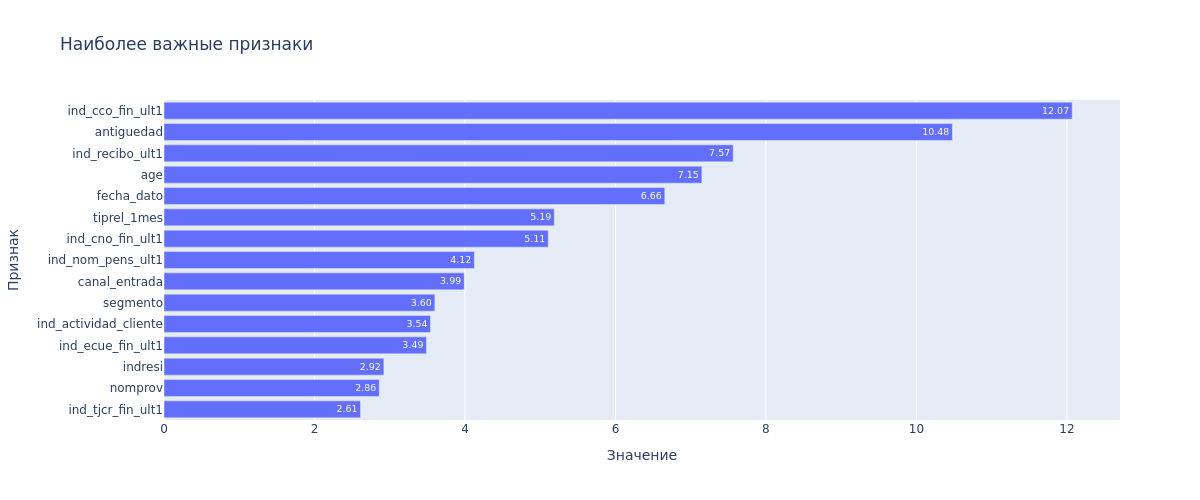

In [50]:
feat_importance = pd.DataFrame({
    "Признак": X_test.columns,
    "Важность": cbfs_model.get_feature_importance()}
).sort_values(by="Важность", ascending=False).set_index("Признак")
fig = feat_importance.head(15).plot(
    kind="barh", text_auto=True,
    title="Наиболее важные признаки",
    labels={"value": "Значение"})
fig.update_traces(texttemplate="%{x:.2f}")
fig.update_layout(
    height=500, width=1200, 
    showlegend=False,
    yaxis=dict(autorange="reversed"))
fig.show(renderer="png")

Модель определила наиболее важными признаками стаж, возраст, месяц взаимодействия и канал прихода. Также в топе продукты, которыми пользовались клиенты. Оценим наименее значимые признаки.

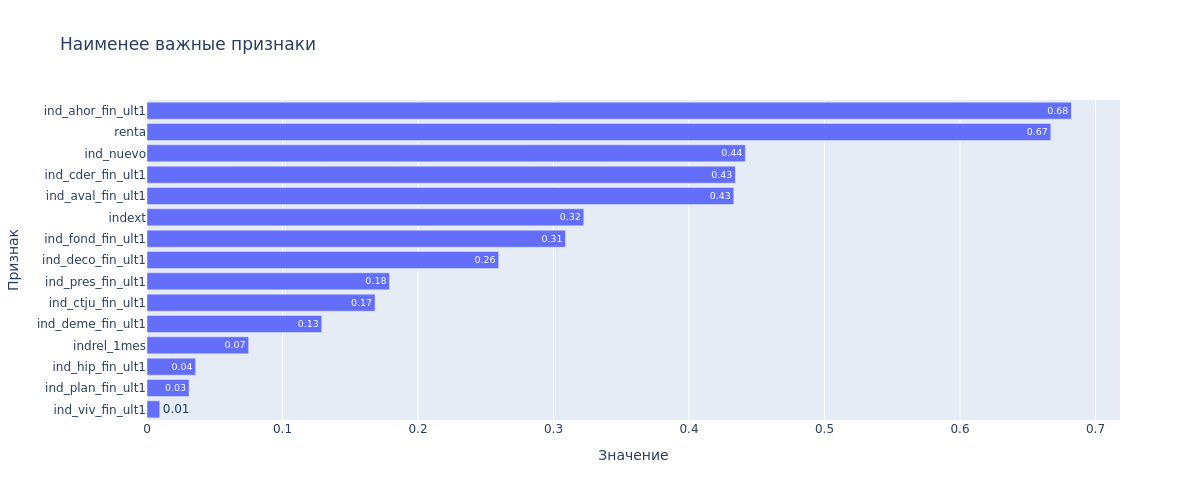

In [51]:
fig = feat_importance.tail(15).plot(
    kind="barh", text_auto=True,
    title="Наименее важные признаки",
    labels={"value": "Значение"})
fig.update_traces(texttemplate="%{x:.2f}")
fig.update_layout(
    height=500, width=1200, 
    showlegend=False,
    yaxis=dict(autorange="reversed"))
fig.show(renderer="png")

К наименее важным признакам модель отнесла довольно много продуктов, из остальных признаков самая низкая важность у активности клиента на начало месяца. Отбор признаков производить не будем, так как использованные клиентами продукты лучше не удалять - они в первую очередь являются признаком того, что в следующем месяце таких же продуктов не будет.

### Логирование в MLflow

In [52]:
if MLFLOW:
    with mlflow.start_run(run_name="Multi-label stratified model", 
                        experiment_id=experiment_id) as run:
        mlflow.log_metrics(metrics)
        mlflow.catboost.log_model(
            cb_model=cbfs_model, artifact_path="model",
            registered_model_name=REGISTRY_MODEL_NAME,
            signature=infer_signature(
                X_test, probas),
            input_example=X_test.sample(
                15, random_state=RANDOM_STATE),
            await_registration_for=60,
            pip_requirements="requirements.txt")
    
    print("Run ID:", run.info.run_id)

Registered model 'bank_products_3PX' already exists. Creating a new version of this model...
2025/05/08 07:02:01 INFO mlflow.tracking._model_registry.client: Waiting up to 60 seconds for model version to finish creation. Model name: bank_products_3PX, version 6


Run ID: 08d537336c8e497d89d1f77750027cbf


Created version '6' of model 'bank_products_3PX'.


## Сохранение данных и выбор модели для Веб-сервиса

Сохраним тестовую выборку в S3 бакет для использования в Веб-сервисе в качестве данных за последний месяц. Целевые признаки сохраним для использования скриптом тестирования.

In [53]:
# Сохранение тестовой выборки в S3
X_test.to_parquet(
    TEST_DUMP, engine="pyarrow",
    storage_options=STORAGE_OPTIONS)

# Сохранение таргета для скрипта тестирования
y_test.assign(ncodpers=df.loc[test_mask, "ncodpers"]) \
    .set_index("ncodpers").to_parquet(
        os.path.join("testing", "test_data.parquet"))

Переведем последнюю модель MLflow в стадию Production, так как подготовленный Веб-сервис по умолчанию забирает последнюю модель в этой стадии.

In [54]:
if MLFLOW:
    models = client.get_latest_versions(
        name=REGISTRY_MODEL_NAME, stages=["None", "Production"])
    last_model = max(models, key=lambda m: int(m.version))
    client.transition_model_version_stage(
        name=REGISTRY_MODEL_NAME, 
        version=last_model.version, 
        stage="Production",
        archive_existing_versions=True)

## Итоговые выводы

1. В рамках проекта проведен глубокий исследовательский анализ данных (EDA):
- удалены все записи с пропусками по большинству полей, остальные пропуски заполнены на основании последующих значений у клиента, либо заглушками типа `unknown`;
- в датасете было выявлено большое количество аномалий, которые были исправлены;
- пропуски по доходу были заполнены нулями, так как нет понимания насколько актуальны эти сведения для старых клиентов, в датасете имеются несовершеннолетние и могут быть безработные, иждивенцы, либо находящиеся на социальном обеспечении клиенты. Также возможно не для всех продуктов запрашивались сведения по доходам и точно не запрашивались для резидентов других стран;
- выбросы были исправлены только по возрасту клиентов, так как при анализе признака, в том числе по банковским продуктам, имелись подозрения на наличие выбросов. Для этого была подготовлена регрессионная модель Random Forest и значения с самыми большими остатками были исправлены на предсказания модели;
- подготовлен трансформер для всех преобразований датасета.

2. Проведены эксперименты по подготовке базовых моделей на этапе моделирования:
- подготовлен трансформер для выделения из датасета записей, имеющих сведения о продуктах в следующем месяце, а также целевые значения для таких записей;
- подготовлена и протестирована базовая модель с двухстадийным подходом - получение рекомендаций от ALS и последующее ранжирование с помощью CatBoost Classifier;
- подготовлена и протестирована базовая модель многометочной (multi-label) классификации - CatBoost Classifier с функцией потери MultiLogLoss;
- среди базовых определена лучшая - модель multi-label классификации, которая показывает существенное преимущество по сравнению с двухстадийным подходом и не требует дополнительной подготовки датасета;
- проведен эксперимент по сэмплированию данных - сохранение редких классов в признаках, сэмплирование привело к несущественному росту основной метрики MAP@3, однако по метрике Recall@3 дало даже небольшое снижение, дальнейшие эксперименты трубуют дополнительных ресурсов;
- результат EDA, а также все трансформеры и модели логированы в MLflow;
- произведена выгрузка тестового датасета, а последняя версия модели переведена в стадию Production для использования Веб-сервисом.

3. Подготовлен FastAPI Веб-сервис, который имеет следующую функциональность:
- загрузка модели из MLflow (по имени, flavor и стадии модели, любая модель с методом predict_proba) и датасета за последний месяц для получения предсказаний;
- предоставление списка клиентов по продукту, вероятность приобретения которых не ниже порога;
- предоставление ТОП-k рекомендаций по клиенту;
- рассчет метрик по предоставленным сведениям об использовании клиентами продуктов в новом месяце;

4. Дополнительно подготовлены: 
- сервис мониторинга на базе Prometheus и Grafana - собирает метрики по Веб-сервису и предсказаниям модели (метрики модели и количество успешных предсказаний);
- скрипт для тестирования Веб-сервиса.

Рекомендации по дальнейшим экспериментам:
- увеличить количество негативных записей с мажорными классами признаков после сэмплирования (требуется дополнительный объем оперативной памяти для обучения модели);
- провести подбор гиперпараметров для модели (требуется дополнительные временные и вычислительные ресурсы).